In [1]:
from pptools.io import load_nc_arr, ZarrWriter, ZarrReader
from pptools.visualize import Visualizer
import datetime
import matplotlib.pyplot as plt
import dask.array as da

vis = Visualizer()

In [2]:
orig_tomo_path = '/home/bg/Developer/Data/datasets/iron_ore/1190502_GOH_6_morethan250microns/tomoHiRes_GM_SS_AC_nc/*.nc'
orig_mask_path = '/home/bg/Developer/Data/datasets/iron_ore/1190502_GOH_6_morethan250microns/labelsHiRes_GM_SS_AC_CAC_EDT_WST_RM_RSC_MCL_MV_MV_MCL_nc/*.nc'
tomo = load_nc_arr(orig_tomo_path)
mask = load_nc_arr(orig_mask_path)

(4900, 1869, 1869)


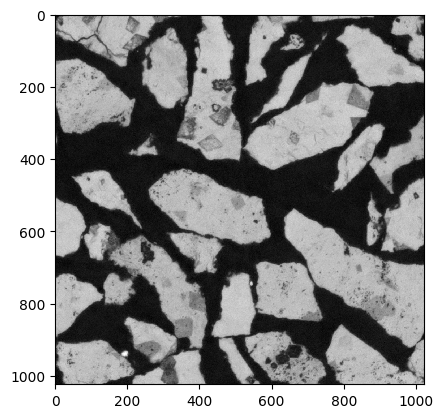

In [3]:
print(tomo.shape)
vis.plot_tomo(tomo[1000][500:1524, 500:1524], show_ticks=True)
vis.show()

In [4]:
tomo_subset = tomo[1000:2024, 500:1524, 500:1524]
mask_subset = mask[1000:2024, 500:1524, 500:1524]

In [5]:
def int16_to_uint8(block: da.array) -> da.array:
    """Convert an int16 tomography block to uint8 using fixed clipping bounds."""
    in_min = 10000
    in_max = 32767
    scale = 255.0 / (in_max - in_min)

    chunk_f32 = block.astype(da.float32)
    shifted = chunk_f32 - in_min
    scaled = shifted * scale
    clipped = da.clip(scaled, 0, 255).astype(da.uint8)
    return clipped

In [6]:
tomo_uint8_subset = int16_to_uint8(tomo_subset)

In [7]:
tomo_writer = ZarrWriter(
    path='/home/bg/Developer/particle-pack-generation/data/toy_data_GOH_6_250/tomo.zarr',
    shape=tomo_uint8_subset.shape,
    dtype=tomo_uint8_subset.dtype,
    chunks=(256, 256, 256),
    shards=(512, 512, 512),
    comp_level=0,
    attributes={
        'description': 'Converted from NetCDF to Zarr format',
        'source': str(orig_tomo_path),
        'timestamp': datetime.datetime.now().isoformat(),
        'crop_start': (1000, 500, 500),
        'crop_end': (2024, 1524, 1524),
    },
    overwrite=True
)
tomo_writer.write(tomo_uint8_subset)

In [20]:
mask_writer = ZarrWriter(
    path='/home/bg/Developer/particle-pack-generation/data/toy_data_GOH_6_250/mask.zarr',
    shape=mask_subset.shape,
    dtype=mask_subset.dtype,
    chunks=(256, 256, 256),
    shards=(512, 512, 512),
    comp_level=1,
    attributes={
        'description': 'Converted from NetCDF to Zarr format',
        'source': str(orig_mask_path),
        'timestamp': datetime.datetime.now().isoformat(),
        'crop_start': (1000, 500, 500),
        'crop_end': (2024, 1524, 1524),
    }
)
mask_writer.write(mask_subset)

In [ ]:
# Check written file

In [31]:
toy_tomo = ZarrReader('/home/bg/Developer/particle-pack-generation/data/toy_data_GOH_6_250/tomo.zarr').get_dask_array()
toy_mask = ZarrReader('/home/bg/Developer/particle-pack-generation/data/toy_data_GOH_6_250/mask.zarr').get_dask_array()

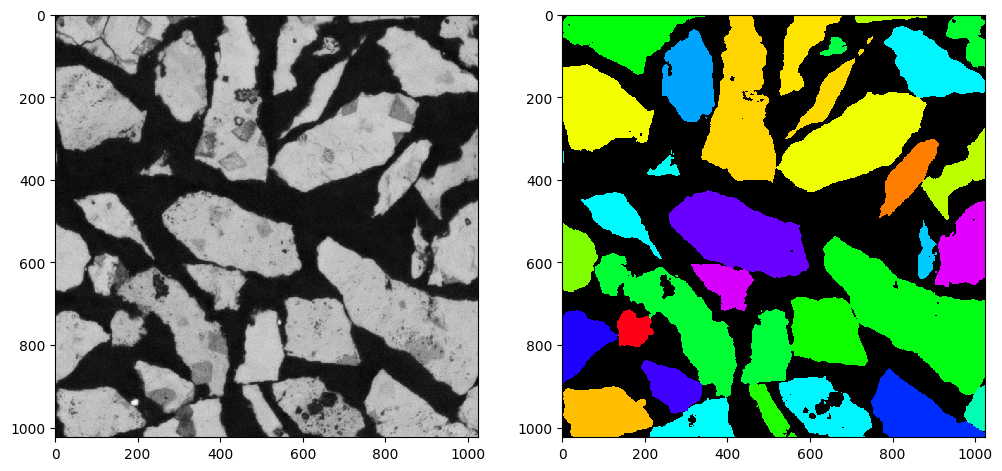

In [32]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
vis.plot_tomo(toy_tomo[0], show_ticks=True, ax=ax[0])
vis.plot_mask(toy_mask[0], show_ticks=True, ax=ax[1])
vis.show()